In [540]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron,LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [541]:
### Last Two digits of my Roll No
a=0
b=8


In [542]:
### Dataset Construction
np.random.seed(42)

### Number of points per Class = 40+a
n_points = 40+a
### Gaussian noise standard deviation
noise_sigma = 0.01*a
### class separation
theta = np.deg2rad(15*b)

### Creating the Clean dataset
X0_clean = np.random.uniform(-1,1,size=(n_points,2))

### Adding the noise
noise = np.random.normal(0,noise_sigma,size=(n_points,2))
X0_noisy = X0_clean + noise

### Rotain Matrix (2D)
R = np.array([[np.cos(theta),-np.sin(theta)],
 [np.sin(theta),np.cos(theta)]])

### create second class by rotaing inputs
X1 =X0_noisy @ R.T


In [543]:
n_points

40

In [544]:
### Dataset Completetion
X = np.vstack((X0_noisy, X1))
y = np.array([0]*n_points+[1]*n_points)

In [545]:
### Shape of the Dataset
print(X.shape)
print(y.shape)

(80, 2)
(80,)


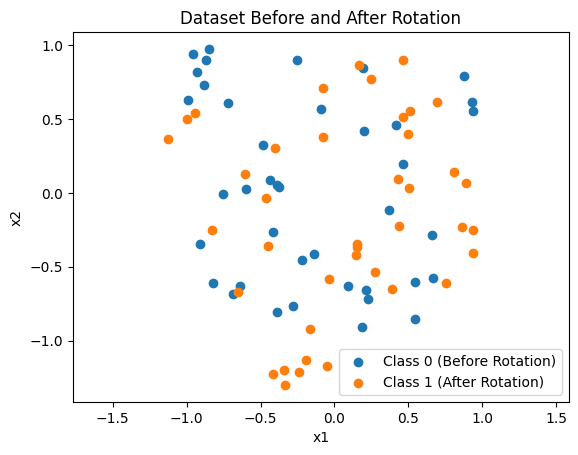

In [546]:
### Visualize The Data
# Plot Class 0
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0 (Before Rotation)")
# Plot Class 1
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1 (After Rotation)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Before and After Rotation")
plt.axis("equal")
plt.legend()
plt.show()


In [547]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Boundary plot function

In [548]:
import numpy as np
import matplotlib.pyplot as plt
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y)
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ["Class 0", "Class 1"])
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.show()

### Preceptron

In [549]:
perceptron = Perceptron(max_iter=10,eta0=0.1)
perceptron.fit(X_scaled,y)
print("Perceptron accuracy :",perceptron.score(X_scaled,y))

Perceptron accuracy : 0.575


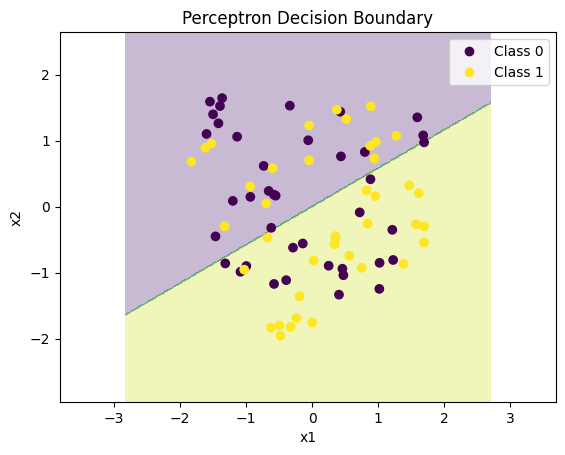

In [550]:
plot_decision_boundary(
    perceptron,
    X_scaled,
    y,
    "Perceptron Decision Boundary"
)

In [ ]:
### Trying the defferent values of Perceptron
eta0 = [0.001,0.01,0.05,0.1,0.5,1,5,10]
for i in eta0:
  perceptron = Perceptron(max_iter=12,eta0=i)
  perceptron.fit(X_scaled,y)
  print("Perceptron accuracy :",perceptron.score(X_scaled,y))


Perceptron accuracy : 0.575
Perceptron accuracy : 0.575
Perceptron accuracy : 0.575
Perceptron accuracy : 0.575
Perceptron accuracy : 0.575
Perceptron accuracy : 0.575
Perceptron accuracy : 0.575
Perceptron accuracy : 0.575


### Logistic Regression

In [552]:
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)
print("Logistic Regression accuracy:", log_reg.score(X_scaled, y))

Logistic Regression accuracy: 0.6


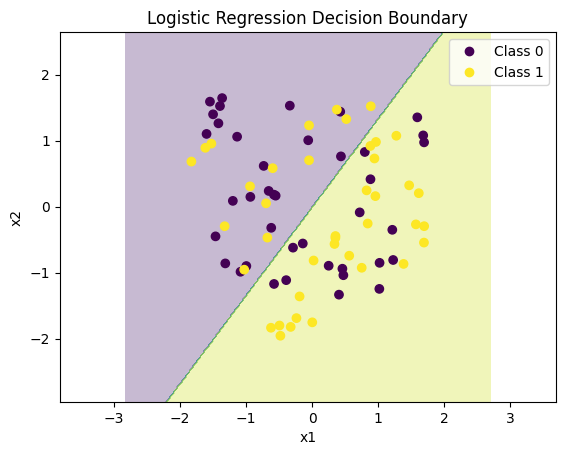

In [553]:
plot_decision_boundary(
    log_reg,
    X_scaled,
    y,
    "Logistic Regression Decision Boundary"
)


In [554]:
### Trying the defferent values for Logetic Regression
C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
for i in C_values:
  reg = LogisticRegression(C=i,solver='lbfgs')
  reg.fit(X_scaled,y)
  print("Logestic accuracy :",reg.score(X_scaled,y))

Logestic accuracy : 0.6
Logestic accuracy : 0.6
Logestic accuracy : 0.6
Logestic accuracy : 0.6
Logestic accuracy : 0.6
Logestic accuracy : 0.6
Logestic accuracy : 0.6
Logestic accuracy : 0.6
